# Mapping von Institutionen

In [82]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [83]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [84]:
client = bigquery.Client(project='subugoe-collaborative')

In [85]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            -- WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen' # in der KB-Kodierung als GAU kodiert
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 6612 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 316 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 315 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 5488 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 4564 THEN 'Carl von Ossietzky Universität Oldenburg'
                            ELSE ''
                        END AS parent_name,
                        CASE 
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS fak_name,
                        inst.address_full AS raw_affiliation_string,
                        doi
                    FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                    JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND primary_location.source.type='journal'
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111' -- Universität Vechta
                        ) OR kb_inst.inst_id IN (
                             -- Ergänzung von Suborganisationen (Oldenburg)
                             445, -- 'Evangelisches Krankenhaus Oldenburg'
                             6612, -- 'UMO - Universitätsmedizin Oldenburg'
                             316, -- 'Klinikum Oldenburg gGmbH'
                             315, -- 'Pius-Hospital Oldenburg'
                             5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                             4564 -- Institute for Science Networking Oldenburg GmbH
                            )
                        )
                    ORDER BY fak_name
                    """).to_dataframe()

In [86]:
#kb.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [87]:
kb.head()

,parent_name,fak_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,4Helmholtz Institute for Functional Marine Bio...,10.1525/elementa.2021.00117
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1038/s41598-022-17999-y
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1159762
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1128322
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.5194/esd-13-1677-2022


In [88]:
with open('institution_mapping/mapping_tables_fak/clausthal.json', 'r') as file:
    CLAUSTHAL_MAPPING = json.load(file)

In [89]:
with open('institution_mapping/mapping_tables_fak/emden.json', 'r') as file:
    EMDEN_MAPPING = json.load(file)

In [90]:
with open('institution_mapping/mapping_tables_fak/gau.json', 'r') as file:
    GAU_MAPPING = json.load(file)

In [91]:
with open('institution_mapping/mapping_tables_fak/hawk.json', 'r') as file:
    HAWK_MAPPING = json.load(file)

In [92]:
with open('institution_mapping/mapping_tables_fak/hbk.json', 'r') as file:
    HBK_MAPPING = json.load(file)

In [93]:
with open('institution_mapping/mapping_tables_fak/hildesheim.json', 'r') as file:
    HILDESHEIM_MAPPING = json.load(file)

In [94]:
with open('institution_mapping/mapping_tables_fak/hmtmh.json', 'r') as file:
    HMTMH_MAPPING = json.load(file)

In [95]:
with open('institution_mapping/mapping_tables_fak/hsh.json', 'r') as file:
    HSH_MAPPING = json.load(file)

In [96]:
with open('institution_mapping/mapping_tables_fak/hsosnabrueck.json', 'r') as file:
    HSOSNABRÜCK_MAPPING = json.load(file)

In [97]:
with open('institution_mapping/mapping_tables_fak/jade.json', 'r') as file:
    JADE_MAPPING = json.load(file)

In [98]:
with open('institution_mapping/mapping_tables_fak/leibniz.json', 'r') as file:
    LEIBNIZ_MAPPING = json.load(file)

In [99]:
with open('institution_mapping/mapping_tables_fak/leuphana.json', 'r') as file:
    LEUPHANA_MAPPING = json.load(file)

In [100]:
with open('institution_mapping/mapping_tables_fak/mhh.json', 'r') as file:
    MHH_MAPPING = json.load(file)

In [101]:
with open('institution_mapping/mapping_tables_fak/oldenburg.json', 'r') as file:
    OLDENBURG_MAPPING = json.load(file)

In [102]:
with open('institution_mapping/mapping_tables_fak/ostfalia.json', 'r') as file:
    OSTFALIA_MAPPING = json.load(file)

In [103]:
with open('institution_mapping/mapping_tables_fak/tiho.json', 'r') as file:
    TIHO_MAPPING = json.load(file)

In [104]:
with open('institution_mapping/mapping_tables_fak/tubraunschweig.json', 'r') as file:
    TUBRAUNSCHWEIG_MAPPING = json.load(file)

In [105]:
with open('institution_mapping/mapping_tables_fak/uosnabrueck.json', 'r') as file:
    UOSNABRÜCK_MAPPING = json.load(file)

In [106]:
with open('institution_mapping/mapping_tables_fak/vechta.json', 'r') as file:
    VECHTA_MAPPING = json.load(file)

In [107]:
MAPPING_DICT_FAK = {
    'Technische Universität Clausthal': CLAUSTHAL_MAPPING,
    'Hochschule Emden/Leer': EMDEN_MAPPING,
    'Georg-August-Universität Göttingen': GAU_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_MAPPING,
    'Hochschule für Bildende Künste Braunschweig': HBK_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_MAPPING,
    'Hochschule für Musik, Theater und Medien Hannover': HMTMH_MAPPING,
    'Hochschule Hannover': HSH_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_MAPPING,
    'Stiftung Tierärztliche Hochschule Hannover': TIHO_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_MAPPING,
    'Universität Vechta': VECHTA_MAPPING
}

In [108]:
map_df = kb.copy()

In [109]:
def map_fak(address: str, mapping_dict: dict) -> Union[str, None]:
    for k, v in mapping_dict.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [110]:
def map_umg(address: str) -> Union[str, None]:
    with open('institution_mapping/mapping_tables_dept/gau.json', 'r') as file:
        MAPPING_DICT_DEPT = json.load(file)
    for k, v in MAPPING_DICT_DEPT.get('Universitätsmedizin Göttingen (UMG)').items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [111]:
for k, v in MAPPING_DICT_FAK.items():
    map_df.loc[map_df['parent_name'] == k, 'fak_name'] = \
        map_df.loc[map_df['parent_name'] == k]['raw_affiliation_string'].apply(map_fak, mapping_dict=v)

In [112]:
map_df.loc[map_df.fak_name == 'Universitätsmedizin Göttingen (UMG)', 'parent_name'] = 'Universitätsmedizin Göttingen'
map_df.loc[map_df.parent_name == 'Universitätsmedizin Göttingen', 'fak_name'] = 'not assigned'

In [113]:
map_df.loc[map_df['parent_name'] == 'Universitätsmedizin Göttingen', 'fak_name'] = \
    map_df.loc[map_df['parent_name'] == 'Universitätsmedizin Göttingen']['raw_affiliation_string'].apply(map_umg)

In [114]:
map_df.head()

,parent_name,fak_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,4Helmholtz Institute for Functional Marine Bio...,10.1525/elementa.2021.00117
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1038/s41598-022-17999-y
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1159762
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1128322
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.5194/esd-13-1677-2022


In [115]:
liste_aller_hochschulen = list(map_df.parent_name.unique())

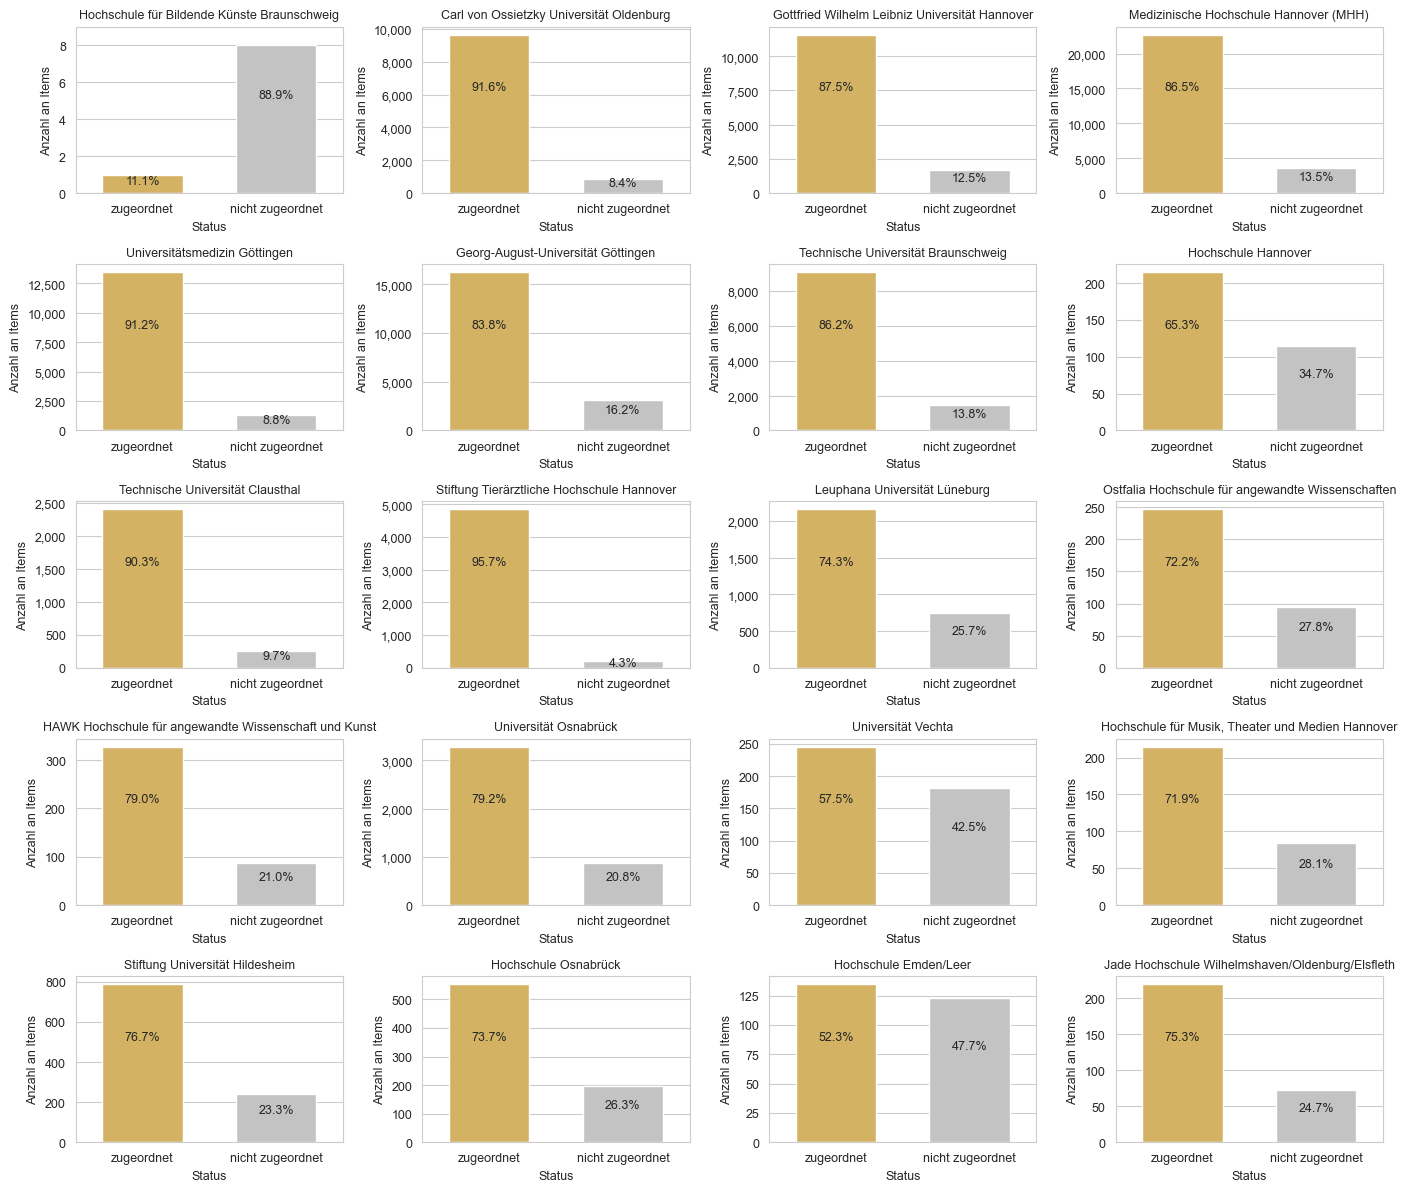

In [116]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    parent_name = liste_aller_hochschulen[i-1]

    df_temp = map_df[map_df.parent_name == parent_name].copy()
    df_temp.fillna('Nicht zugeordnet', inplace=True)

    number_of_items_mapped = df_temp[df_temp.fak_name != 'Nicht zugeordnet'].doi.count()
    number_of_items_not_mapped = df_temp[df_temp.fak_name == 'Nicht zugeordnet'].doi.count()

    prop = df_temp[df_temp.fak_name != 'Nicht zugeordnet'].doi.count() / df_temp.doi.count()

    data = {
        'mapped_indicator': ['zugeordnet', 'nicht zugeordnet'],
        'n': [number_of_items_mapped, number_of_items_not_mapped],
        'prop': [format(prop, '.1%'), format(1-prop, '.1%')]
    }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='mapped_indicator', 
                y='n', 
                width=0.6,
                hue='mapped_indicator',
                palette=['#E5BA52', '#c3c3c3'],
                ax=ax).set_title(parent_name, fontdict=dict(fontsize=9, fontweight=500))

    for idx, row in df.iterrows():
        ax.text(row['mapped_indicator'], 
                row['n'] / 1.5, 
                row['prop'], 
                verticalalignment='center', 
                horizontalalignment='center', 
                fontdict=dict(fontsize=9, fontweight=500))

    if parent_name == 'Hochschule für Bildende Künste Braunschweig':
        ax.set_ylim(0, 9)
        ax.set_yticks(range(0, 9, 2))

    ax.set(xlabel='Status', ylabel='Anzahl an Items')

    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()

plt.show()
fig.savefig('mapping.png', format='png', bbox_inches='tight', dpi=600)

In [117]:
map_df.sample(10)

,parent_name,fak_name,raw_affiliation_string,doi
93998,Medizinische Hochschule Hannover (MHH),Zentrum Innere Medizin,"Department of Gastroenterology, Hepatology and...",10.1038/s41467-024-54181-6
3584,Medizinische Hochschule Hannover (MHH),Zentrum für Neurologische Medizin,Department of Clinical Neuroimmunology and Neu...,10.1038/s41467-023-39046-8
29916,Medizinische Hochschule Hannover (MHH),"Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilku...","Medizinische Hochschule Hannover, Klinik für H...",10.1055/s-0044-1784792
14321,Medizinische Hochschule Hannover (MHH),"Klinik für Dermatologie, Allergologie und Vene...",de Hannover Medical School Dept. of Dermatolog...,10.1111/ddg.14906_g
78580,Gottfried Wilhelm Leibniz Universität Hannover,None,"Leibniz Universität Hannover, D-30167 Hannover...",10.3847/1538-4357/abe939
29590,Universitätsmedizin Göttingen,Klinik für Neurologie,"Department of Neurology, University Medicine G...",10.1038/s41598-021-81697-4
93107,Medizinische Hochschule Hannover (MHH),"Zentrum für Pathologie, Forensik und Genetik","Institute of Legal Medicine, Hannover Medical ...",10.1007/s00414-020-02421-x
25723,Universität Osnabrück,Fachbereich Biologie / Chemie,"Center of Cellular Nanoanalytics (CellNanOs), ...",10.1016/j.jbc.2023.102915
29055,Stiftung Universität Hildesheim,Fachbereich III: Sprach- und Informationswisse...,"University of Hildesheim , Institute of Interc...",10.1515/zfal-2024-2022
93423,Medizinische Hochschule Hannover (MHH),None,Hannover Medical School and the German Center ...,10.1183/13993003.01107-2023


## GERiT Level 2

In [118]:
with open('institution_mapping/mapping_tables_dept/clausthal.json', 'r') as file:
    CLAUSTHAL_DEPT_MAPPING = json.load(file)

In [119]:
with open('institution_mapping/mapping_tables_dept/emden.json', 'r') as file:
    EMDEN_DEPT_MAPPING = json.load(file)

In [120]:
with open('institution_mapping/mapping_tables_dept/gau.json', 'r') as file:
    GAU_DEPT_MAPPING = json.load(file)

In [121]:
with open('institution_mapping/mapping_tables_dept/hawk.json', 'r') as file:
    HAWK_DEPT_MAPPING = json.load(file)

In [122]:
#with open('institution_mapping/mapping_tables_dept/hbk.json', 'r') as file:
#    HBK_DEPT_MAPPING = json.load(file)

In [123]:
with open('institution_mapping/mapping_tables_dept/hildesheim.json', 'r') as file:
    HILDESHEIM_DEPT_MAPPING = json.load(file)

In [124]:
#with open('institution_mapping/mapping_tables_dept/hmtmh.json', 'r') as file:
#    HMTMH_DEPT_MAPPING = json.load(file)

In [125]:
with open('institution_mapping/mapping_tables_dept/hsh.json', 'r') as file:
    HSH_DEPT_MAPPING = json.load(file)

In [126]:
with open('institution_mapping/mapping_tables_dept/hsosnabrueck.json', 'r') as file:
    HSOSNABRÜCK_DEPT_MAPPING = json.load(file)

In [127]:
with open('institution_mapping/mapping_tables_dept/jade.json', 'r') as file:
    JADE_DEPT_MAPPING = json.load(file)

In [128]:
with open('institution_mapping/mapping_tables_dept/leibniz.json', 'r') as file:
    LEIBNIZ_DEPT_MAPPING = json.load(file)

In [129]:
with open('institution_mapping/mapping_tables_dept/leuphana.json', 'r') as file:
    LEUPHANA_DEPT_MAPPING = json.load(file)

In [130]:
with open('institution_mapping/mapping_tables_dept/mhh.json', 'r') as file:
    MHH_DEPT_MAPPING = json.load(file)

In [131]:
with open('institution_mapping/mapping_tables_dept/oldenburg.json', 'r') as file:
    OLDENBURG_DEPT_MAPPING = json.load(file)

In [132]:
with open('institution_mapping/mapping_tables_dept/ostfalia.json', 'r') as file:
    OSTFALIA_DEPT_MAPPING = json.load(file)

In [133]:
#with open('institution_mapping/mapping_tables_dept/tiho.json', 'r') as file:
#    TIHO_DEPT_MAPPING = json.load(file)

In [134]:
with open('institution_mapping/mapping_tables_dept/tubraunschweig.json', 'r') as file:
    TUBRAUNSCHWEIG_DEPT_MAPPING = json.load(file)

In [135]:
with open('institution_mapping/mapping_tables_dept/uosnabrueck.json', 'r') as file:
    UOSNABRÜCK_DEPT_MAPPING = json.load(file)

In [136]:
with open('institution_mapping/mapping_tables_dept/vechta.json', 'r') as file:
    VECHTA_DEPT_MAPPING = json.load(file)

In [137]:
MAPPING_DICT_DEPT = {
    'Technische Universität Clausthal': CLAUSTHAL_DEPT_MAPPING,
    'Hochschule Emden/Leer': EMDEN_DEPT_MAPPING,
    'Georg-August-Universität Göttingen': GAU_DEPT_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_DEPT_MAPPING,
    #'Hochschule für Bildende Künste Braunschweig': HBK_DEPT_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_DEPT_MAPPING,
    #'Hochschule für Musik, Theater und Medien Hannover': HMTMH_DEPT_MAPPING,
    'Hochschule Hannover': HSH_DEPT_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_DEPT_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_DEPT_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_DEPT_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_DEPT_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_DEPT_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_DEPT_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_DEPT_MAPPING,
    #'Stiftung Tierärztliche Hochschule Hannover': TIHO_DEPT_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_DEPT_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_DEPT_MAPPING,
    'Universität Vechta': VECHTA_DEPT_MAPPING
}

In [138]:
def map_dept(row: pd.Series, mapping_dict: dict) -> Union[str, None]:

    address = row['raw_affiliation_string']
    faculty = row['fak_name']
    
    
    if faculty in mapping_dict:
        for k, v in mapping_dict.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [139]:
for k, v in MAPPING_DICT_DEPT.items():
    map_df.loc[map_df['parent_name'] == k, 'dept_name'] = \
        map_df.loc[map_df['parent_name'] == k].apply(map_dept, axis=1, mapping_dict=v)

In [140]:
map_df.head(5)

,parent_name,fak_name,raw_affiliation_string,doi,dept_name
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,4Helmholtz Institute for Functional Marine Bio...,10.1525/elementa.2021.00117,None
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1038/s41598-022-17999-y,None
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1159762,None
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmars.2023.1128322,None
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.5194/esd-13-1677-2022,None


## Verknüpfung mit GERiT ID

In [141]:
map_df_with_gerit = map_df.copy()

In [142]:
map_df_with_gerit.loc[map_df_with_gerit['parent_name'] == 'Universitätsmedizin Göttingen', 'parent_name'] = 'Georg-August-Universität Göttingen'

In [143]:
gerit_ids = pd.read_csv('gerit_inst_with_ids.csv')

In [144]:
gerit_ids.head()

,dfg_id,inst_name,level,parent_name,dfg_id_parent
0,14332,Bibliotheks- und Informationssystem (BIS),level0,Carl von Ossietzky Universität Oldenburg,10233
1,14349,Center für lebenslanges Lernen (C3L),level0,Carl von Ossietzky Universität Oldenburg,10233
2,19052,"CMC - Center for Migration, Education and Cult...",level0,Carl von Ossietzky Universität Oldenburg,10233
3,35245680,COAST - Zentrum für Umwelt- und Nachhaltigkeit...,level0,Carl von Ossietzky Universität Oldenburg,10233
4,25628,ecco-ecology + communication Unternehmensberat...,level0,Carl von Ossietzky Universität Oldenburg,10233


In [145]:
gerit_ids[gerit_ids.dfg_id == 13002060]

,dfg_id,inst_name,level,parent_name,dfg_id_parent
1226,13002060,Abteilung Experimentelle Neurodegeneration,level1,Georg-August-Universität Göttingen,10236


In [146]:
map_df_with_gerit = map_df_with_gerit.merge(gerit_ids[['parent_name', 'inst_name', 'dfg_id', 'dfg_id_parent']], 
                                            left_on=['parent_name', 'fak_name'], 
                                            right_on=['parent_name', 'inst_name'], 
                                            how='left')

In [147]:
map_df_with_gerit.drop(['inst_name'], axis=1, inplace=True)
map_df_with_gerit.rename(columns={'dfg_id': 'dfg_id_fak'}, inplace=True)

In [148]:
map_df_with_gerit['dfg_id_fak']= map_df_with_gerit['dfg_id_fak'].astype('Int64')
map_df_with_gerit['dfg_id_parent']= map_df_with_gerit['dfg_id_parent'].astype('Int64')

In [149]:
map_df_with_gerit = map_df_with_gerit.merge(gerit_ids[['parent_name', 'inst_name', 'dfg_id']], 
                                            left_on=['parent_name', 'dept_name'], 
                                            right_on=['parent_name', 'inst_name'], 
                                            suffixes=(None, '_dept'),
                                            how='left')

In [150]:
map_df_with_gerit.drop(['inst_name'], axis=1, inplace=True)
map_df_with_gerit.rename(columns={'dfg_id': 'dfg_id_dept'}, inplace=True)

In [151]:
map_df_with_gerit['dfg_id_fak']= map_df_with_gerit['dfg_id_fak'].astype('Int64')
map_df_with_gerit['dfg_id_dept']= map_df_with_gerit['dfg_id_dept'].astype('Int64')
map_df_with_gerit['dfg_id_parent']= map_df_with_gerit['dfg_id_parent'].astype('Int64')

In [152]:
umg_all_inst = list(map_df[map_df.parent_name == 'Universitätsmedizin Göttingen'].fak_name.unique())
umg_all_inst.remove(None)

In [153]:
map_df_with_gerit.loc[(map_df_with_gerit['parent_name'] == 'Georg-August-Universität Göttingen') \
    & (map_df_with_gerit['fak_name'].isin(umg_all_inst)),
    'parent_name'] = 'Universitätsmedizin Göttingen'

In [154]:
map_df_with_gerit.sample(5)

,parent_name,fak_name,raw_affiliation_string,doi,dept_name,dfg_id_fak,dfg_id_parent,dfg_id_dept
89295,Technische Universität Braunschweig,Carl-Friedrich-Gauß-Fakultät,Peter L. Reichertz Institute for Medical Infor...,10.1055/s-0042-1742506,Department Informatik,13362,10240,20688270
41756,Stiftung Tierärztliche Hochschule Hannover,Institut für Physiologie und Zellbiologie,"Institute of Physiology and Cell Biology, Univ...",10.1016/j.livsci.2021.104583,NaN,13867,10249,<NA>
73253,Medizinische Hochschule Hannover (MHH),Zentrum für Radiologie,Institute of Diagnostic and Interventional Rad...,10.1183/23120541.00399-2021,Institut für Diagnostische und Interventionell...,13809,10247,29470
734,Carl von Ossietzky Universität Oldenburg,Universitätsmedizin Oldenburg,"Department of Gastroenterology, Evangelisches ...",10.4103/eus-d-20-00252,None,<NA>,<NA>,<NA>
29407,Georg-August-Universität Göttingen,None,"University of Göttingen, Germany",10.1016/j.worlddev.2019.104862,None,<NA>,<NA>,<NA>


## Erstellung von Samples

In [155]:
for hochschule in liste_aller_hochschulen:

    sample_size = 100

    df_hochschule = map_df[map_df.parent_name == hochschule].copy()

    if len(df_hochschule) < 100:
        sample_size = len(df_hochschule)

    df_sample = df_hochschule.sample(sample_size, random_state=42)

    filename = hochschule

    if hochschule == 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth':
        filename = 'Jade Hochschule Wilhelmshaven Oldenburg Elsfleth'

    if hochschule == 'Hochschule Emden/Leer':
        filename = 'Hochschule Emden Leer'

    df_sample[['doi', 'parent_name', 'raw_affiliation_string', 'fak_name', 'dept_name']].to_csv(f'samples/{filename}_sample.csv', index=False)